In [ ]:
from google.colab import drive

drive.mount('/content/drive')
import pandas as pd

# show all columns / rows
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# don't truncate long strings in cells
pd.set_option("display.max_colwidth", None)

# optional: widen the console display
pd.set_option("display.width", None)

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_parquet('/content/drive/MyDrive/NLP Final Project/docs_with_topics.parquet')

In [ ]:
df_ent = pd.read_parquet('/content/drive/MyDrive/NLP Final Project/entity_topic_td_summary.parquet')

In [ ]:
!pip install bertopic
!pip install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.2 MB/s eta 0:00:00


In [ ]:
from tqdm import tqdm
import time
from bertopic import BERTopic

print("Loading BERTopic model...")

for _ in tqdm(range(1), desc="Loading model"):
    topic_model = BERTopic.load("/content/drive/MyDrive/NLP Final Project/bertopic_model")

print("Model loaded.")

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Loading BERTopic model...


Loading model: 100%|██████████| 1/1 [00:01<00:00,  1.26s/it]

Model loaded.


In [ ]:
topic_model.get_topic(79)

[['air india', 0.14284297379984023],
 ['plane', 0.05854588661438066],
 ['airline', 0.03814137796718045],
 ['passengers', 0.03526568944850806],
 ['plane crash', 0.03220603146205252],
 ['pilots', 0.027281620845943412],
 ['civil aviation', 0.02313379330947752],
 ['tata', 0.023132715756439475],
 ['crashed', 0.021626578524175297],
 ['incident', 0.02161932227315621]]

In [ ]:
# Topic -> Industry map (based on your topic_labels)
topic_to_industry = {
    # --- AI / GenAI ---
    0:  "Artificial Intelligence",
    11: "Artificial Intelligence",
    12: "Artificial Intelligence",
    17: "Artificial Intelligence",
    28: "Artificial Intelligence",
    45: "Artificial Intelligence",
    52: "Artificial Intelligence",
    70: "Artificial Intelligence",
    83: "Artificial Intelligence",
    86: "Artificial Intelligence",

    # --- Semiconductors / Hardware supply chain ---
    13: "Semiconductors & Hardware",
    48: "Semiconductors & Hardware",

    # --- Consumer Tech / Devices ---
    9:  "Consumer Tech & Devices",
    27: "Consumer Tech & Devices",
    35: "Consumer Tech & Devices",
    39: "Consumer Tech & Devices",
    40: "Consumer Tech & Devices",
    84: "Consumer Tech & Devices",

    # --- Software / Cloud / DevTools ---
    19: "Software & Cloud",
    33: "Software & Cloud",
    97: "Software & Cloud",

    # --- Cybersecurity / Digital Risk ---
    16: "Cybersecurity",
    74: "Cybersecurity",
    64: "Cybersecurity",

    # --- Capital Markets / Investing ---
    5:  "Capital Markets",
    34: "Capital Markets",
    72: "Capital Markets",
    90: "Capital Markets",
    51: "Capital Markets",  # FX / gold markets fits here too

    # --- Crypto / Digital Assets ---
    3:  "Crypto & Digital Assets",
    47: "Crypto & Digital Assets",
    49: "Crypto & Digital Assets",
    54: "Crypto & Digital Assets",
    22: "Crypto & Digital Assets",  # mixed investing bucket but still finance/crypto-heavy

    # --- FinTech / Digital Banking ---
    81: "FinTech",

    # --- Startups / VC ---
    4:  "Venture & Startups",

    # --- Healthcare / Biotech ---
    2:  "Healthcare & Biotech",

    # --- Energy / Climate ---
    14: "Energy & Climate",
    58: "Energy & Climate",
    50: "Telecom",  # telecom sustainability is closer to telecom than energy

    # --- Automotive / Aerospace / Robotics / Logistics ---
    29: "Automotive & Logistics",
    61: "Automotive & Aerospace",
    79: "Aviation",

    # --- E-Commerce / Retail / Food ---
    20: "E-Commerce & Retail",
    55: "Restaurants & Food",

    # --- Media / Entertainment / Sports / Gaming ---
    21: "Media & Entertainment",
    26: "Media & Entertainment",
    42: "Media & Entertainment",
    63: "Media & Entertainment",
    78: "Media & Entertainment",
    93: "Media & Entertainment",
    68: "Gambling & Betting",

    # --- Real Estate ---
    85: "Real Estate",

    # --- Travel / Hospitality ---
    41: "Travel & Hospitality",
    91: "Travel & Hospitality",

    # --- Professional Services / Consulting / Workforce ---
    62: "Professional Services",
    24: "Professional Services",
    94: "Professional Services",

    # --- Education / Academia ---
    25: "Education",
    30: "Education",
    53: "Education",

    # --- Government / Politics / Regulation / Conflict ---
    1:  "Government & Policy",
    7:  "Government & Policy",
    37: "Government & Policy",
    69: "Government & Policy",

    # --- Nonprofit / Religion / Human Rights ---
    44: "Nonprofit / Religion / Human Rights",
    56: "Nonprofit / Religion / Human Rights",
    75: "Nonprofit / Religion / Human Rights",

    # --- News / Journalism (regional + press distribution) ---
    6:  "News & Journalism",
    8:  "News & Journalism",
    10: "News & Journalism",
    23: "News & Journalism",
    31: "News & Journalism",
    32: "News & Journalism",
    38: "News & Journalism",
    57: "News & Journalism",
    59: "News & Journalism",
    60: "News & Journalism",
    65: "News & Journalism",
    66: "News & Journalism",
    73: "News & Journalism",
    76: "News & Journalism",
    77: "News & Journalism",
    80: "News & Journalism",
    82: "News & Journalism",
    87: "News & Journalism",
    88: "News & Journalism",
    95: "News & Journalism",

    # --- Personal / Lifestyle ---
    36: "Lifestyle & Personal",
    71: "Lifestyle & Personal",
    89: "Public Safety",
    96: "Public Safety",

    # --- Outliers ---
    -1: "Outliers",
}



In [ ]:
df['industry'] = df['topic'].map(topic_to_industry)
topics = df.loc[df['industry'] != 'Outliers']

In [ ]:
df_ent['industry'] = df['topic'].map(topic_to_industry)

In [ ]:
import re
ai_terms = [
    "GPT-4",
    "GPT",
    "ChatGPT",
    "OpenAI",
    "Gemini",
    "Bard",
    "Claude",
    "Copilot",
    "LLM",
    "DeepSeek",
    'AI'
]
ai_pattern = re.compile("|".join(map(re.escape, ai_terms)), re.IGNORECASE)


In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()

In [ ]:
# how many AI terms appear in each text:
topics["ai_mentions"] = topics["clean_text"].progress_apply(
    lambda x: len(ai_pattern.findall(x))
)

  0%|          | 0/92373 [00:00<?, ?it/s]

In [ ]:
topics["month"] = topics["date"].dt.to_period("M")

In [ ]:
industry_ai_exposure = (
    topics.groupby("industry")
      .agg(
          ai_mentions=("ai_mentions", "sum"),
          articles=("clean_text", "count")
      )
)

industry_ai_exposure["ai_exposure"] = (
    industry_ai_exposure["ai_mentions"] /
    industry_ai_exposure["articles"]
)

# average number of AI mentions per article
industry_ai_exposure = industry_ai_exposure.sort_values(
    "ai_exposure", ascending=False
)

In [ ]:
industry_ai_exposure

,ai_mentions,articles,ai_exposure
industry,,,
Real Estate,26199,299,87.622074
News & Journalism,513623,12632,40.660465
Restaurants & Food,16044,422,38.018957
Capital Markets,125728,3688,34.091106
Media & Entertainment,119520,3509,34.060986
E-Commerce & Retail,36051,1141,31.595968
Energy & Climate,49011,1649,29.721649
Consumer Tech & Devices,135906,4582,29.660847
Lifestyle & Personal,29216,989,29.540950


In [ ]:
topics["ai_article_share"] = topics["ai_mentions"] > 0

industry_ai_exposure = (
    topics.groupby("industry")
      .agg(
          ai_articles=("ai_article_share", "sum"),
          articles=("clean_text", "count")
      )
)


In [ ]:
industry_ai_exposure

,ai_articles,articles
industry,,
Artificial Intelligence,14533,14635
Automotive & Aerospace,386,396
Automotive & Logistics,838,848
Aviation,316,319
Capital Markets,3681,3688
Consumer Tech & Devices,4571,4582
Crypto & Digital Assets,4625,4635
Cybersecurity,1946,1946
E-Commerce & Retail,1141,1141


In [ ]:
industry_ai_exposure["avg_ai_density"] = (
    industry_ai_exposure["ai_mentions"] /
    industry_ai_exposure["articles"]
)

KeyError: 'ai_mentions'

In [ ]:
industry_ai_exposure

,ai_articles,articles
industry,,
Artificial Intelligence,14533,14635
Automotive & Aerospace,386,396
Automotive & Logistics,838,848
Aviation,316,319
Capital Markets,3681,3688
Consumer Tech & Devices,4571,4582
Crypto & Digital Assets,4625,4635
Cybersecurity,1946,1946
E-Commerce & Retail,1141,1141


In [ ]:
topics["word_count"] = topics["clean_text"].str.split().str.len()

In [ ]:
topics["ai_article"] = (topics["ai_mentions"] > 0).astype(int)

In [ ]:
industry_ai_exposure = (
    topics.groupby("industry")
    .agg(
        ai_mentions=("ai_mentions", "sum"),
        ai_articles=("ai_article", "sum"),
        articles=("clean_text", "count"),
        total_words=("clean_text", lambda x: x.str.split().str.len().sum())
    )
)

In [ ]:
industry_ai_exposure["avg_ai_density"] = (
    industry_ai_exposure["ai_mentions"] /
    industry_ai_exposure["total_words"]
)

In [ ]:
# Metric 1: intensity (mentions per article)
industry_ai_exposure["ai_mentions_per_article"] = (
    industry_ai_exposure["ai_mentions"] /
    industry_ai_exposure["articles"]
)

# Metric 2: breadth (share of articles mentioning AI)
industry_ai_exposure["ai_article_share"] = (
    industry_ai_exposure["ai_articles"] /
    industry_ai_exposure["articles"]
)

In [ ]:
industry_ai_exposure

,ai_mentions,ai_articles,articles,total_words,avg_ai_density,ai_mentions_per_article,ai_article_share
industry,,,,,,,
Artificial Intelligence,212602,14533,14635,6338020,0.033544,14.526956,0.993030
Automotive & Aerospace,6186,386,396,449053,0.013776,15.621212,0.974747
Automotive & Logistics,5086,838,848,112905,0.045047,5.997642,0.988208
Aviation,7732,316,319,287315,0.026911,24.238245,0.990596
Capital Markets,125728,3681,3688,3248718,0.038701,34.091106,0.998102
Consumer Tech & Devices,135906,4571,4582,4643821,0.029266,29.660847,0.997599
Crypto & Digital Assets,130000,4625,4635,3872084,0.033574,28.047465,0.997843
Cybersecurity,51417,1946,1946,1591434,0.032309,26.421891,1.000000
E-Commerce & Retail,36051,1141,1141,962511,0.037455,31.595968,1.000000


In [ ]:
pd.options.display.float_format = "{:.4f}".format
industry_time = (
    topics.groupby(["industry", "month"])
    .agg(
        ai_mentions=("ai_mentions", "sum"),
        articles=("clean_text", "count")
    )
    .reset_index()
)

industry_time["ai_mentions_per_article"] = (
    industry_time["ai_mentions"] /
    industry_time["articles"]
)

industry_time = industry_time.sort_values(["industry", "month"])

industry_time["ai_acceleration"] = (
    industry_time.groupby("industry")["ai_mentions_per_article"]
    .diff()
)

industry_acceleration = (
    industry_time.groupby("industry")["ai_acceleration"]
    .mean()
    .reset_index(name="ai_intensity_acceleration")
)

industry_acceleration

,industry,ai_intensity_acceleration
0,Artificial Intelligence,0.3140
1,Automotive & Aerospace,1.3710
2,Automotive & Logistics,0.3085
3,Aviation,0.0270
4,Capital Markets,0.3661
5,Consumer Tech & Devices,0.0616
6,Crypto & Digital Assets,0.1890
7,Cybersecurity,0.1008
8,E-Commerce & Retail,0.2120
9,Education,0.4289


In [ ]:
industry_ai_exposure = industry_ai_exposure.merge(
    industry_acceleration,
    on="industry",
    how="left"
)

In [ ]:
industry_ai_exposure

In [ ]:
df_ent['industry'] = df['topic'].map(topic_to_industry)

In [ ]:
import pandas as pd
import networkx as nx
from itertools import combinations

G = nx.Graph()

for topic_id, g in df_ent.groupby("topic"):
    sub = g.groupby("entity", as_index=False)["n_mentions"].sum()
    ents = sub["entity"].tolist()
    mention_map = dict(zip(sub["entity"], sub["n_mentions"]))

    for a, b in combinations(ents, 2):
        w = mention_map[a] + mention_map[b]
        if G.has_edge(a, b):
            G[a][b]["weight"] += w
        else:
            G.add_edge(a, b, weight=w)

pagerank_scores = nx.pagerank(G, weight="weight")

pagerank_df = (
    pd.DataFrame(pagerank_scores.items(), columns=["entity", "pagerank"])
    .sort_values("pagerank", ascending=False)
)

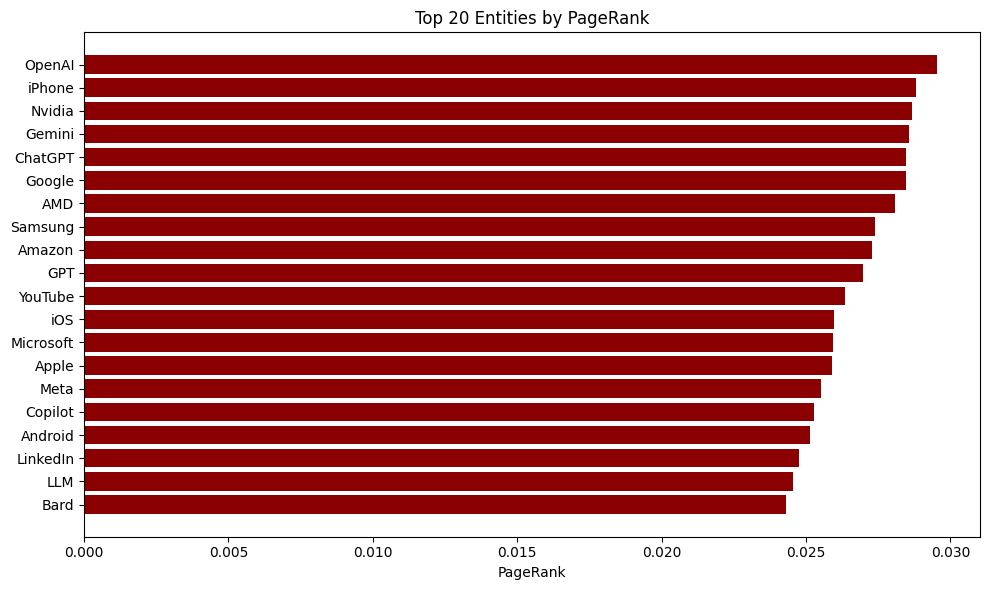

In [ ]:
import matplotlib.pyplot as plt

top_pr = pagerank_df.sort_values("pagerank", ascending=False).head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top_pr["entity"],
    top_pr["pagerank"],
    color="darkred"
)

plt.gca().invert_yaxis()

plt.xlabel("PageRank")
plt.title("Top 20 Entities by PageRank")

plt.tight_layout()
plt.show()

In [ ]:
industry_ai_exposure_plot = industry_ai_exposure[
    (industry_ai_exposure["ai_articles"] > 500) |
    (industry_ai_exposure["articles"] < 10000)
]

In [ ]:
import pandas as pd
import networkx as nx
from itertools import combinations

# 1. Build entity graph from industry-topic co-occurrence
G = nx.Graph()

for (_, _), g in df_ent[["industry", "topic", "entity"]].drop_duplicates().groupby(["industry", "topic"]):
    ents = g["entity"].dropna().unique().tolist()
    for a, b in combinations(ents, 2):
        if G.has_edge(a, b):
            G[a][b]["weight"] += 1
        else:
            G.add_edge(a, b, weight=1)

# 2. Compute PageRank
pr = nx.pagerank(G, weight="weight")
pagerank_df = pd.DataFrame(pr.items(), columns=["entity", "pagerank"])

# 3. Aggregate to industry
industry_pagerank = (
    df_ent[["industry", "entity"]].drop_duplicates()
    .merge(pagerank_df, on="entity", how="left")
    .groupby("industry", as_index=False)
    .agg(avg_pagerank=("pagerank", "mean"))
    .sort_values("avg_pagerank", ascending=False)
)

In [ ]:
industry_ai_exposure = industry_ai_exposure.merge(
    industry_pagerank,
    on="industry",
    how="left"
)

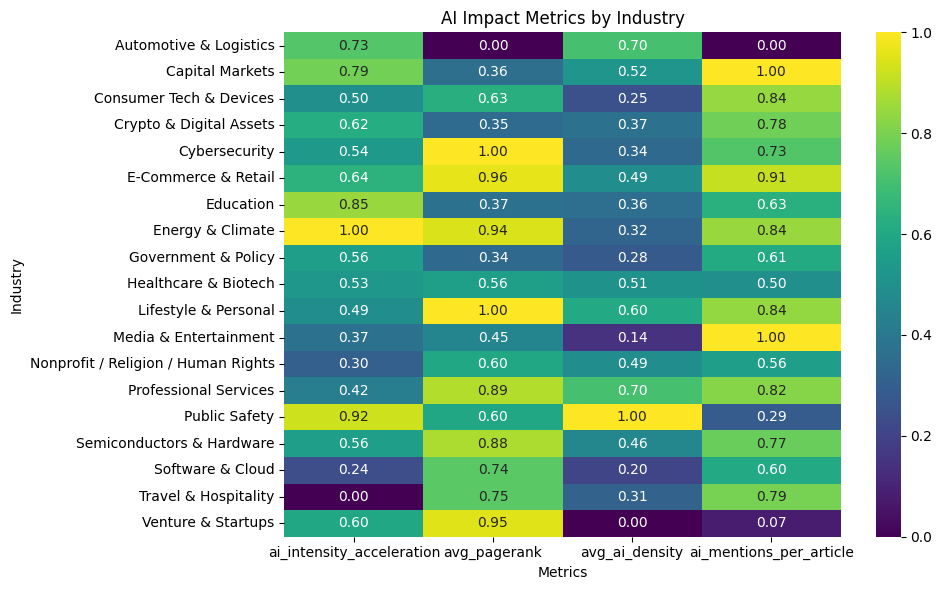

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

industry_ai_exposure_plot = industry_ai_exposure[
    (industry_ai_exposure["ai_articles"] > 500) &
    (industry_ai_exposure["articles"] < 10000)
]

# set industry as index first
metrics = industry_ai_exposure_plot.set_index("industry")[[
    "ai_intensity_acceleration",
    "avg_pagerank",
    "avg_ai_density",
    "ai_mentions_per_article"
]]

# normalize
metrics_scaled = (metrics - metrics.min()) / (metrics.max() - metrics.min())

plt.figure(figsize=(10,6))

sns.heatmap(
    metrics_scaled,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

plt.title("AI Impact Metrics by Industry")
plt.ylabel("Industry")
plt.xlabel("Metrics")

plt.tight_layout()
plt.show()

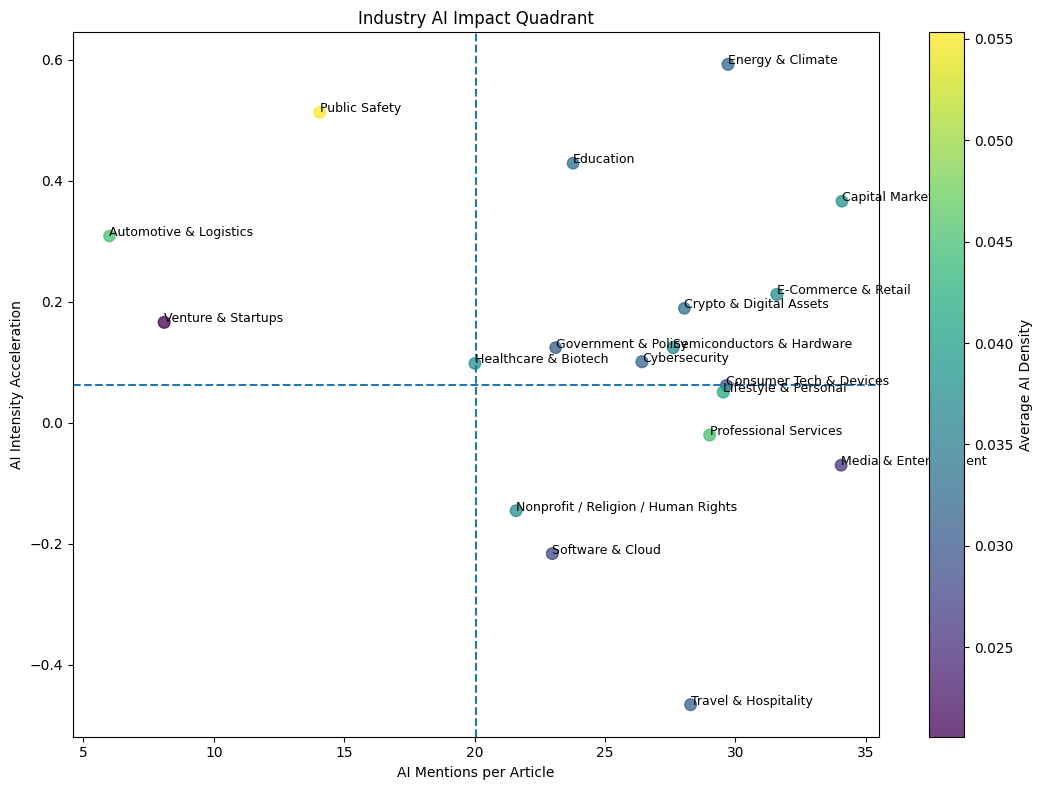

In [ ]:
import matplotlib.pyplot as plt

df_plot = industry_ai_exposure_plot.copy()

x_col = "ai_mentions_per_article"
y_col = "ai_intensity_acceleration"

# midpoint of axis range
x_mid = (df_plot[x_col].min() + df_plot[x_col].max()) / 2
y_mid = (df_plot[y_col].min() + df_plot[y_col].max()) / 2

plt.figure(figsize=(11,8))

plt.scatter(
    df_plot[x_col],
    df_plot[y_col],
    s=df_plot["avg_pagerank"] * 3000,
    c=df_plot["avg_ai_density"],
    cmap="viridis",
    alpha=0.75
)

# divider lines
plt.axvline(x=x_mid, linestyle="--")
plt.axhline(y=y_mid, linestyle="--")

# industry labels
for _, row in df_plot.iterrows():
    plt.text(row[x_col], row[y_col], row["industry"], fontsize=9)

# axis limits
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()


plt.xlabel("AI Mentions per Article")
plt.ylabel("AI Intensity Acceleration")
plt.title("Industry AI Impact Quadrant")

plt.colorbar(label="Average AI Density")

plt.tight_layout()
plt.show()

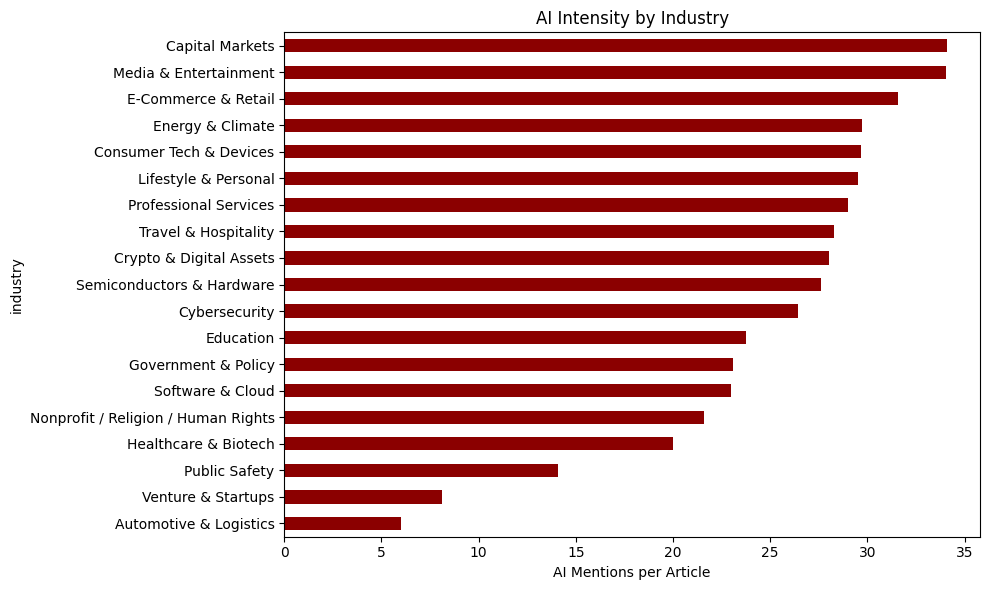

In [ ]:
import matplotlib.pyplot as plt

industry_ai_exposure_plot.sort_values(
    "ai_mentions_per_article",
    ascending=False
).plot(
    x="industry",
    y="ai_mentions_per_article",
    kind="barh",
    figsize=(10,6),
    legend=False,
    color="darkred"
)

plt.xlabel("AI Mentions per Article")
plt.title("AI Intensity by Industry")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

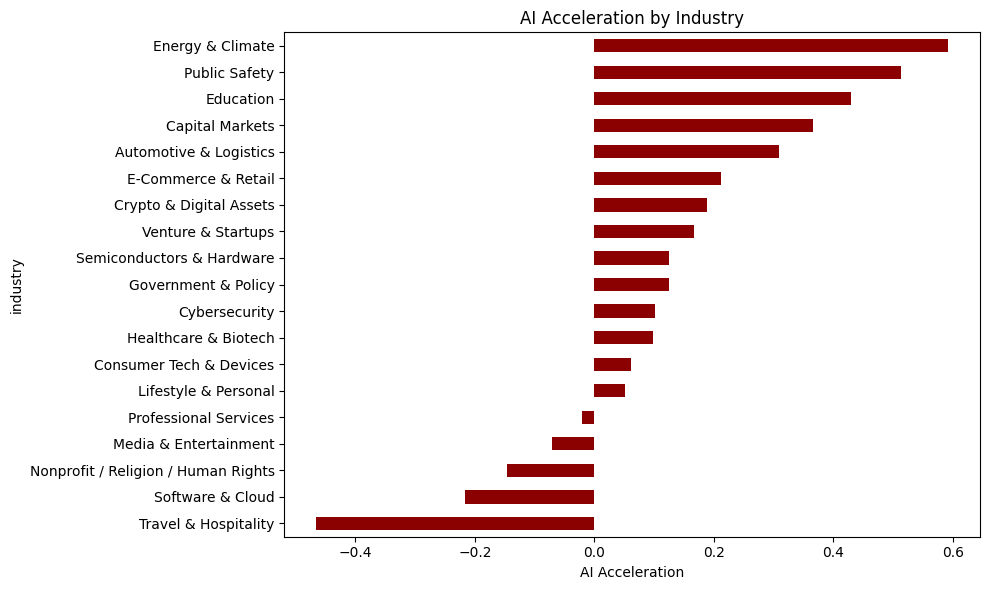

In [ ]:
import matplotlib.pyplot as plt

industry_ai_exposure_plot.sort_values(
    "ai_intensity_acceleration",
    ascending=False
).plot(
    x="industry",
    y="ai_intensity_acceleration",
    kind="barh",
    figsize=(10,6),
    legend=False,
    color="darkred"
)

plt.xlabel("AI Acceleration")
plt.title("AI Acceleration by Industry")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()